<a href="https://colab.research.google.com/github/riku05190/riku-nakamura.github.io/blob/main/starter_bikes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

In [ ]:
train_url = 'https://raw.githubusercontent.com/byui-cse/cse450-course/master/data/bikes.csv'
december_url = 'https://raw.githubusercontent.com/byui-cse/cse450-course/master/data/bikes_december.csv'
mini_url = 'https://raw.githubusercontent.com/byui-cse/cse450-course/master/data/biking_holdout_test_mini.csv'

df_train = pd.read_csv(train_url)
df_december = pd.read_csv(december_url)
df_mini = pd.read_csv(mini_url)

In [ ]:
def preprocess_features(df):
    df_clean = df.copy()
    drop_cols = ['casual', 'registered']
    if 'dteday' in df_clean.columns:
        drop_cols.append('dteday')

    df_clean = df_clean.drop(columns=[col for col in drop_cols if col in df_clean.columns])
    df_clean = df_clean.fillna(0)
    return df_clean

train_clean = preprocess_features(df_train)
december_clean = preprocess_features(df_december)
mini_clean = preprocess_features(df_mini)

target_col = 'count' if 'count' in train_clean.columns else 'cnt' if 'cnt' in train_clean.columns else train_clean.columns[-1]

X = train_clean.drop(columns=[target_col])
y = train_clean[target_col]

X_december = december_clean.copy()
X_mini = mini_clean.copy()

X_encoded = pd.get_dummies(X, drop_first=True)
X_december_encoded = pd.get_dummies(X_december, drop_first=True)
X_mini_encoded = pd.get_dummies(X_mini, drop_first=True)

X_december_final = X_december_encoded.reindex(columns=X_encoded.columns, fill_value=0)
X_mini_final = X_mini_encoded.reindex(columns=X_encoded.columns, fill_value=0)

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_encoded)
X_december_scaled = scaler.transform(X_december_final)
X_mini_scaled = scaler.transform(X_mini_final)

X_train, X_val, y_train, y_val = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [ ]:

model = keras.Sequential([
layers.Dense(128, activation='relu', input_shape=[X_train.shape[1]]),
layers.Dropout(0.2),
layers.Dense(64, activation='relu'),
layers.Dropout(0.2),
layers.Dense(32, activation='relu'),
layers.Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

early_stop = keras.callbacks.EarlyStopping(
monitor='val_loss',
patience=10,
restore_best_weights=True
)

history = model.fit(
X_train, y_train,
validation_data=(X_val, y_val),
epochs=100,
batch_size=64,
callbacks=[early_stop],
verbose=0
)

In [ ]:
def generate_predictions(model, scaled_data):
    preds = model.predict(scaled_data, verbose=0).flatten()
    return np.round(np.clip(preds, 0, None)).astype(int)

preds_december = generate_predictions(model, X_december_scaled)
preds_mini = generate_predictions(model, X_mini_scaled)

df_sub_december = pd.DataFrame({'predictions': preds_december})
df_sub_mini = pd.DataFrame({'predictions': preds_mini})

team_number = "team4"
file_december = team_number + "-module04-predictions-december.csv"
file_mini = team_number + "-module04-predictions-mini.csv"

df_sub_december.to_csv(file_december, index=False)
df_sub_mini.to_csv(file_mini, index=False)




[5/6] Generating Business Insights Visualizations...


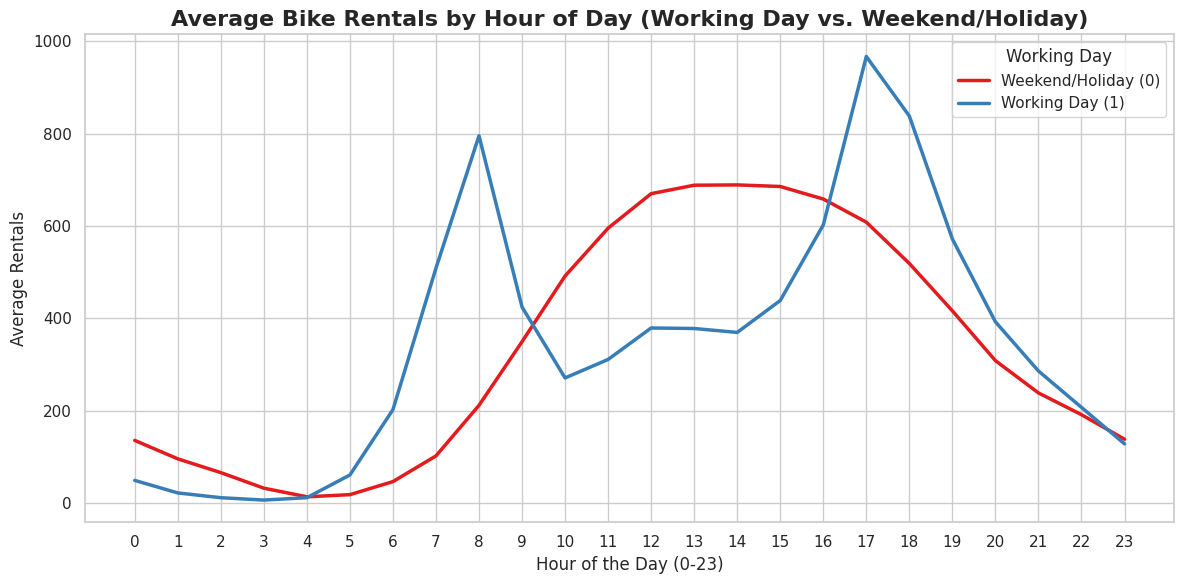

In [ ]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.figure()
df_train['cnt'] = df_train['casual'] + df_train['registered']
sns.lineplot(data=df_train, x='hr', y='cnt', hue='workingday', palette='Set1', errorbar=None, linewidth=2.5)
plt.title('Average Bike Rentals by Hour of Day (Working Day vs. Weekend/Holiday)', fontsize=16, fontweight='bold')
plt.xlabel('Hour of the Day (0-23)', fontsize=12)
plt.ylabel('Average Rentals', fontsize=12)
plt.xticks(range(0, 24))
plt.legend(title='Working Day', labels=['Weekend/Holiday (0)', 'Working Day (1)'])
plt.tight_layout()
plt.show()

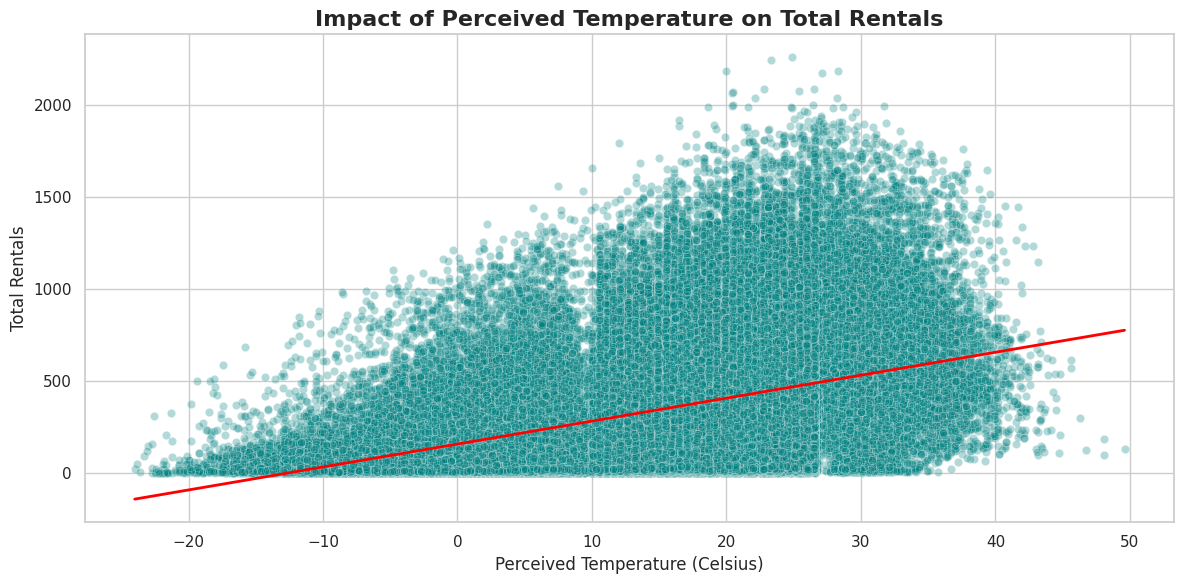

In [ ]:
df_train['perceived_temp_celsius'] = df_train['feels_like_c']

plt.figure()
sns.scatterplot(data=df_train, x='perceived_temp_celsius', y='cnt', alpha=0.3, color='teal')
sns.regplot(data=df_train, x='perceived_temp_celsius', y='cnt', scatter=False, color='red', line_kws={"linewidth":2})
plt.title('Impact of Perceived Temperature on Total Rentals', fontsize=16, fontweight='bold')
plt.xlabel('Perceived Temperature (Celsius)', fontsize=12)
plt.ylabel('Total Rentals', fontsize=12)
plt.tight_layout()
plt.show()

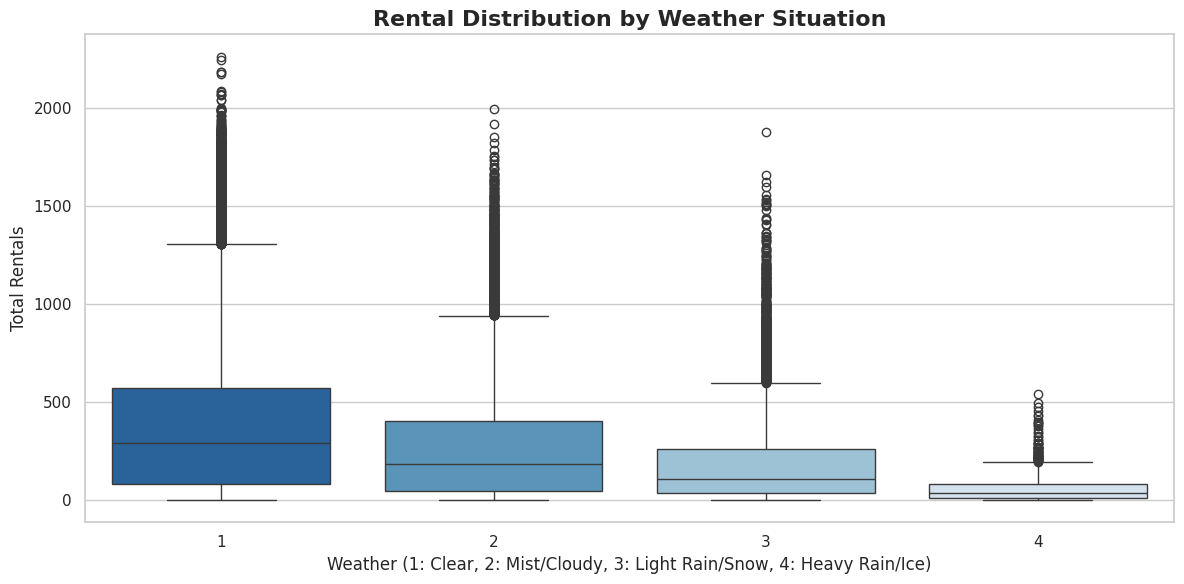

In [ ]:
plt.figure()
sns.boxplot(data=df_train, x='weathersit', y='cnt', palette='Blues_r')
plt.title('Rental Distribution by Weather Situation', fontsize=16, fontweight='bold')
plt.xlabel('Weather (1: Clear, 2: Mist/Cloudy, 3: Light Rain/Snow, 4: Heavy Rain/Ice)', fontsize=12)
plt.ylabel('Total Rentals', fontsize=12)
plt.tight_layout()
plt.show()